In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [131]:
def load_data():
    data = pd.read_excel("data_02a.xlsx")

    X = data[["AT", "V", "AP", "RH"]].values
    y = data["PE"].values

    return X, y

In [132]:
X, y = load_data()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9568, 4)
y shape: (9568,)


In [133]:
def plot_features_vs_target(X, y, feature_names):
    for i, feature_name in enumerate(feature_names):

        plt.figure(figsize=(7, 5))

        plt.scatter(X[:, i], y, alpha=0.4)

        plt.xlabel(feature_name)
        plt.ylabel("PE")
        plt.title(f"{feature_name} vs PE")

        plt.grid()
        plt.show()

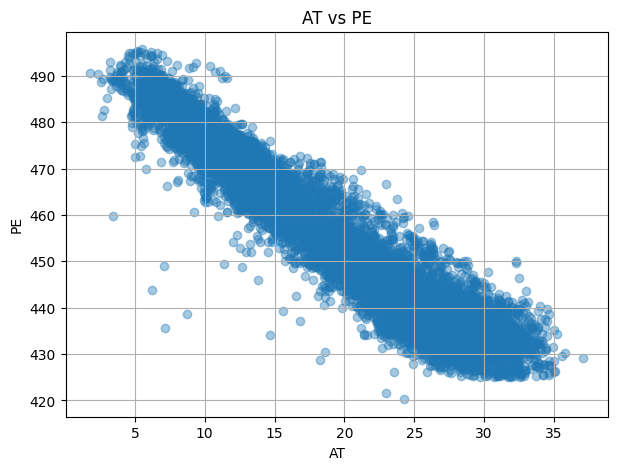

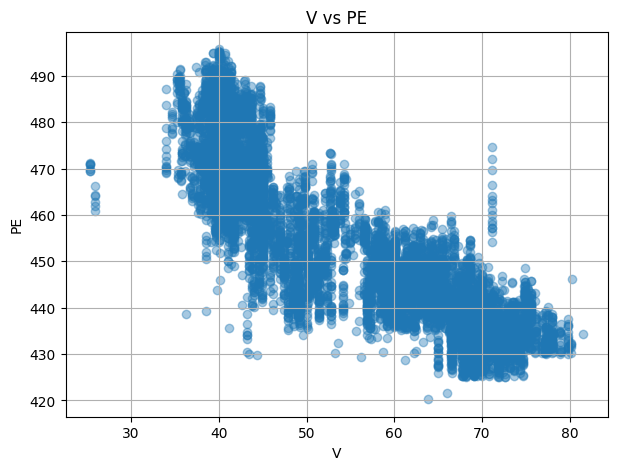

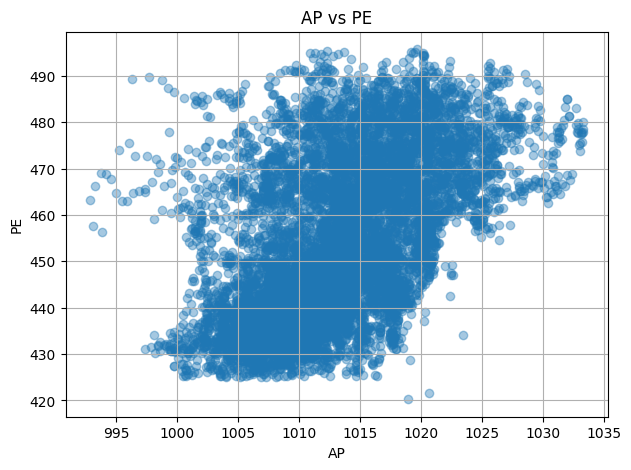

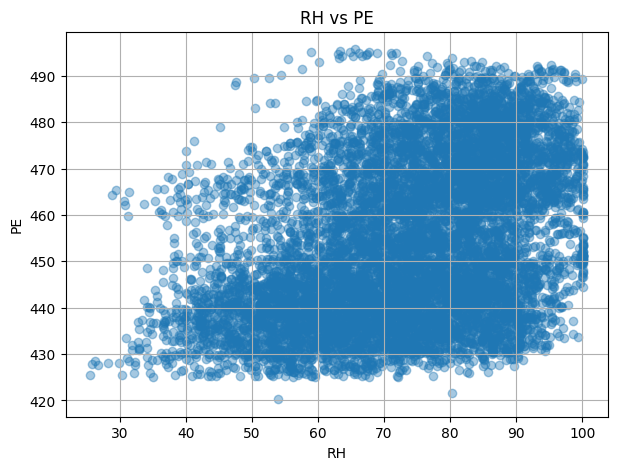

In [134]:
feature_names = ["AT", "V", "AP", "RH"]

plot_features_vs_target(X, y, feature_names)

In [135]:
def add_intercept(X):
    return np.c_[np.ones(X.shape[0]), X]

In [136]:
def predict(X, theta):
    return X @ theta

In [137]:
def compute_cost(X, y, theta):
    m = len(y)

    predictions = predict(X, theta)

    error = predictions - y

    cost = (1 / (2 * m)) * np.sum(error ** 2)

    return cost

In [138]:
def gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta,
    alpha,
    iterations
):
    m = len(y_train)

    train_errors = []
    val_errors = []

    for _ in range(iterations):

        # Prediction
        predictions = predict(X_train, theta)

        # Error
        error = predictions - y_train

        # Gradient
        gradient = (1 / m) * (X_train.T @ error)

        # Update parameters
        theta = theta - alpha * gradient

        # Store errors
        train_cost = compute_cost(X_train, y_train, theta)
        val_cost = compute_cost(X_val, y_val, theta)

        train_errors.append(train_cost)
        val_errors.append(val_cost)

    return theta, train_errors, val_errors

In [139]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [140]:
theta = np.zeros(X_train.shape[1])

In [141]:
theta_unscaled, train_errors_unscaled, val_errors_unscaled = gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta,
    alpha=0.0000005,
    iterations=5000
)

In [142]:
def plot_error_curves(train_errors, val_errors, title):
    plt.figure(figsize=(8, 5))

    plt.plot(train_errors, label="Training Error")
    plt.plot(val_errors, label="Validation Error")

    plt.xlabel("Iterations")
    plt.ylabel("Error")
    plt.title(title)

    plt.legend()
    plt.grid()

    plt.show()

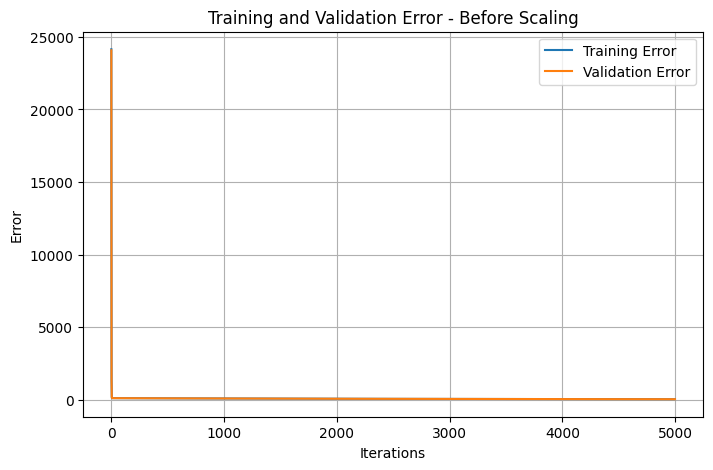

In [143]:
plot_error_curves(
    train_errors_unscaled,
    val_errors_unscaled,
    "Training and Validation Error - Before Scaling"
)

In [144]:
best_val_index = np.argmin(val_errors_unscaled)

best_val_error = val_errors_unscaled[best_val_index]
corresponding_train_error = train_errors_unscaled[best_val_index]

print("Best validation error:", best_val_error)
print("Training error at best validation:", corresponding_train_error)

print("\nLearnt parameters:")
print(theta_unscaled)

Best validation error: 54.33418379021576
Training error at best validation: 55.01326097050594

Learnt parameters:
[-0.20479284 -0.31302073  0.45740508  0.16338426]


In [145]:
def standardize_train_val(X_train, X_val):

    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)

    X_train_scaled = (X_train - mean) / std
    X_val_scaled = (X_val - mean) / std

    return X_train_scaled, X_val_scaled, mean, std

In [146]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [147]:
X_train_scaled, X_val_scaled, mean, std = standardize_train_val(
    X_train_raw,
    X_val_raw
)

In [148]:
X_train_scaled = add_intercept(X_train_scaled)
X_val_scaled = add_intercept(X_val_scaled)

In [149]:
theta = np.zeros(X_train_scaled.shape[1])

In [150]:
theta_scaled, train_errors_scaled, val_errors_scaled = gradient_descent(
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    theta,
    alpha=0.01,
    iterations=1000
)

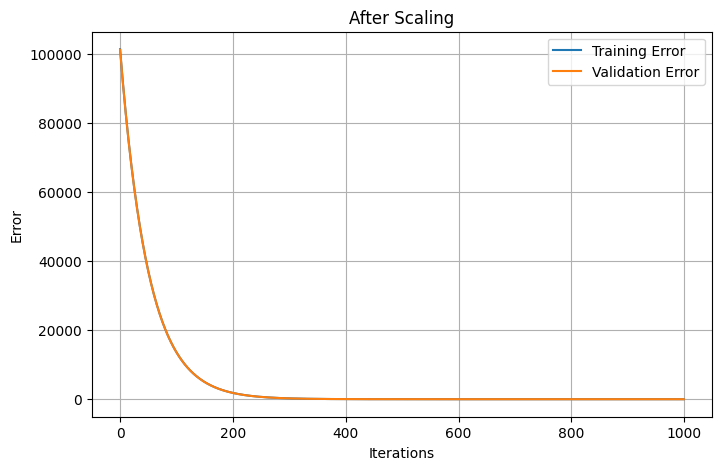

In [151]:
plot_error_curves(
    train_errors_scaled,
    val_errors_scaled,
    "After Scaling"
)

In [152]:
best_val_index_scaled = np.argmin(val_errors_scaled)

best_val_error_scaled = val_errors_scaled[best_val_index_scaled]
corresponding_train_error_scaled = train_errors_scaled[best_val_index_scaled]

print("Best validation error:", best_val_error_scaled)
print(
    "Training error at best validation:",
    corresponding_train_error_scaled
)

print("\nLearnt parameters after scaling:")
print(theta_scaled)

Best validation error: 10.703909122150035
Training error at best validation: 11.130485900045676

Learnt parameters after scaling:
[454.41142162 -11.95688897  -5.01755986   0.89716101  -1.38319795]


In [153]:
print("========== COMPARISON ==========")

print("\nBefore Scaling")
print("Best validation error:", best_val_error)
print("Training error:", corresponding_train_error)
print("Parameters:", theta_unscaled)

print("\nAfter Scaling")
print("Best validation error:", best_val_error_scaled)
print("Training error:", corresponding_train_error_scaled)
print("Parameters:", theta_scaled)

========== COMPARISON ==========

Before Scaling
Best validation error: 54.33418379021576
Training error: 55.01326097050594
Parameters: [-0.20479284 -0.31302073  0.45740508  0.16338426]

After Scaling
Best validation error: 10.703909122150035
Training error: 11.130485900045676
Parameters: [454.41142162 -11.95688897  -5.01755986   0.89716101  -1.38319795]


##Polynomial regression

In [154]:
def load_polynomial_data():
    data = pd.read_csv("data_02b.csv")

    X = data.iloc[:, 0].values
    y = data.iloc[:, 1].values

    return X, y

In [155]:
X, y = load_polynomial_data()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (391,)
y shape: (391,)


In [156]:
def plot_data(X, y):
    plt.figure(figsize=(8, 5))

    plt.scatter(X, y)

    plt.xlabel("Feature")
    plt.ylabel("Target")
    plt.title("Original Data")

    plt.grid()
    plt.show()

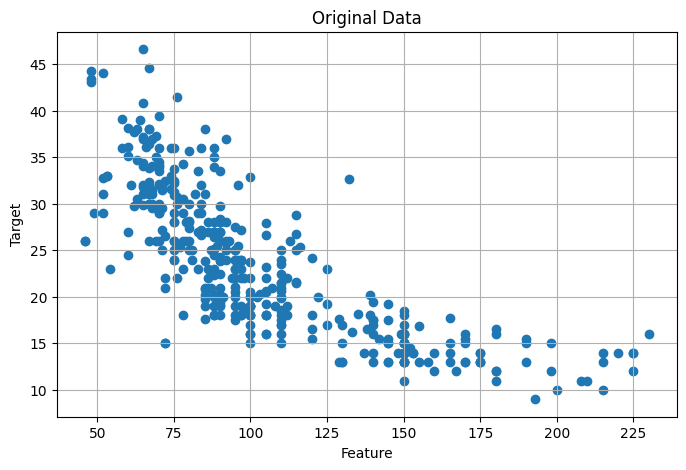

In [157]:
plot_data(X, y)

In [158]:
def create_polynomial_features(X, degree):
    return np.column_stack(
        [X ** i for i in range(1, degree + 1)]
    )

In [159]:
X_poly = create_polynomial_features(X, 3)

print(X_poly[:5])

[[1.650000e+02 2.722500e+04 4.492125e+06]
 [1.500000e+02 2.250000e+04 3.375000e+06]
 [1.500000e+02 2.250000e+04 3.375000e+06]
 [1.400000e+02 1.960000e+04 2.744000e+06]
 [1.980000e+02 3.920400e+04 7.762392e+06]]


In [160]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [161]:
results = {}

In [162]:
degrees = [1, 2, 3]

for degree in degrees:

    # Create polynomial features
    X_train_poly = create_polynomial_features(
        X_train_raw,
        degree
    )

    X_val_poly = create_polynomial_features(
        X_val_raw,
        degree
    )

    # Scale polynomial features
    X_train_poly, X_val_poly, mean, std = standardize_train_val(
        X_train_poly,
        X_val_poly
    )

    # Add intercept
    X_train_poly = add_intercept(X_train_poly)
    X_val_poly = add_intercept(X_val_poly)

    # Initialize theta
    theta = np.zeros(X_train_poly.shape[1])

    # Train
    theta, train_errors, val_errors = gradient_descent(
        X_train_poly,
        y_train,
        X_val_poly,
        y_val,
        theta,
        alpha=0.35,
        iterations=1000
    )

    # Find best validation error
    best_index = np.argmin(val_errors)

    results[degree] = {
        "theta": theta,
        "train_errors": train_errors,
        "val_errors": val_errors,
        "best_val_error": val_errors[best_index],
        "best_train_error": train_errors[best_index],
        "mean": mean,
        "std": std
    }

In [163]:
for degree in degrees:

    print(f"\n========== DEGREE {degree} ==========")

    print(
        "Best validation error:",
        results[degree]["best_val_error"]
    )

    print(
        "Training error:",
        results[degree]["best_train_error"]
    )

    print(
        "Theta:",
        results[degree]["theta"]
    )


========== DEGREE 1 ==========
Best validation error: 12.683061947980802
Training error: 11.95675916995782
Theta: [23.60801282 -6.21660836]

========== DEGREE 2 ==========
Best validation error: 10.18143661199228
Training error: 9.41419182085532
Theta: [ 23.60801282 -18.33891441  12.32614868]

========== DEGREE 3 ==========
Best validation error: 10.095088733225996
Training error: 9.602118460569809
Theta: [ 23.60801282 -13.10211882   1.66210401   5.58117852]


In [164]:
best_degree = min(
    degrees,
    key=lambda d: results[d]["best_val_error"]
)

print("\nBest degree:", best_degree)


Best degree: 3


In [165]:
print("\nBest degree:", best_degree)

print("Learnt parameters:")
print(results[best_degree]["theta"])


Best degree: 3
Learnt parameters:
[ 23.60801282 -13.10211882   1.66210401   5.58117852]


In [166]:
def plot_validation_errors(results, degrees):

    validation_errors = [
        results[d]["best_val_error"]
        for d in degrees
    ]

    plt.figure(figsize=(7, 5))

    plt.bar(
        [str(d) for d in degrees],
        validation_errors
    )

    plt.xlabel("Polynomial Degree")
    plt.ylabel("Best Validation Error")
    plt.title("Validation Error for Different Polynomial Degrees")

    plt.grid(axis="y")

    plt.show()

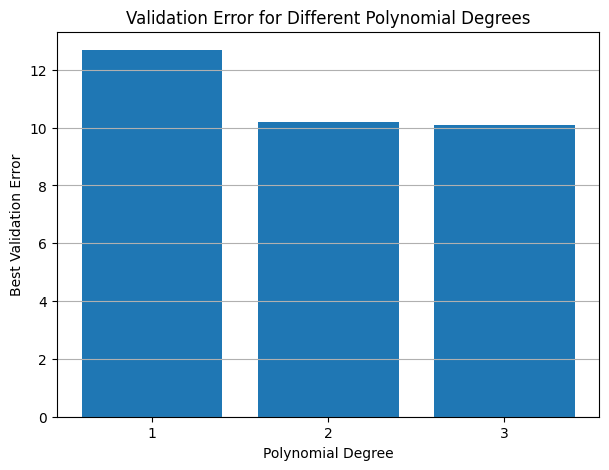

In [167]:
plot_validation_errors(results, degrees)

In [168]:
x_plot = np.linspace(
    X.min(),
    X.max(),
    300
)

In [169]:
def plot_fitted_curves(
    X,
    y,
    results,
    degrees
):

    x_plot = np.linspace(
        X.min(),
        X.max(),
        300
    )

    plt.figure(figsize=(9, 6))

    # Original data
    plt.scatter(
        X,
        y,
        alpha=0.4,
        label="Data"
    )

    for degree in degrees:

        # Create polynomial features
        X_plot_poly = create_polynomial_features(
            x_plot,
            degree
        )

        # Use training mean/std
        mean = results[degree]["mean"]
        std = results[degree]["std"]

        X_plot_poly = (
            X_plot_poly - mean
        ) / std

        # Add intercept
        X_plot_poly = add_intercept(
            X_plot_poly
        )

        # Predict
        y_plot = predict(
            X_plot_poly,
            results[degree]["theta"]
        )

        # Plot
        plt.plot(
            x_plot,
            y_plot,
            label=f"Degree {degree}"
        )

    plt.xlabel("Feature")
    plt.ylabel("Target")
    plt.title("Polynomial Regression for d = 1, 2, 3")

    plt.legend()
    plt.grid()

    plt.show()

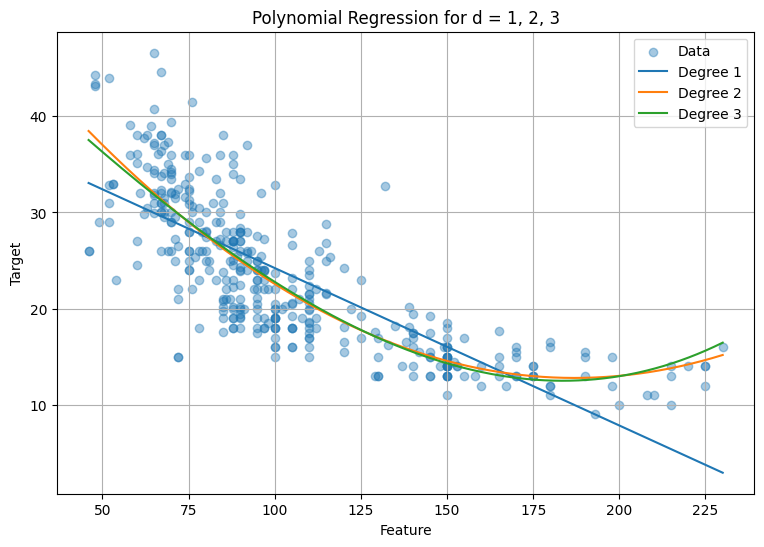

In [170]:
plot_fitted_curves(
    X,
    y,
    results,
    degrees
)

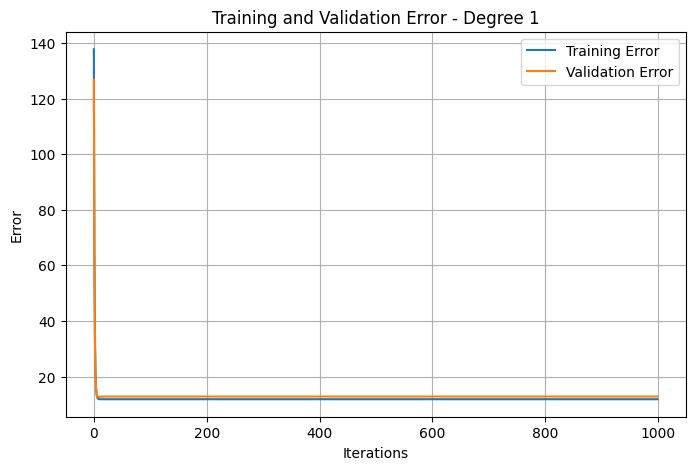

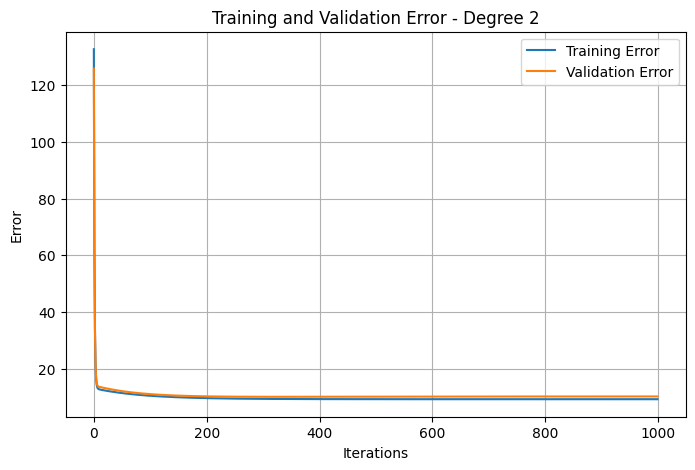

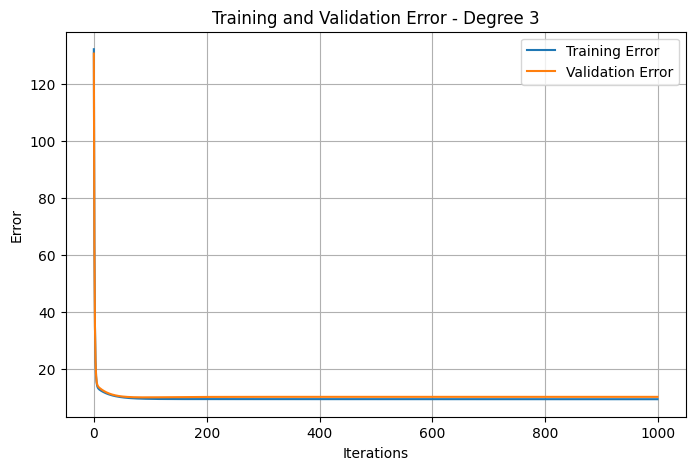

In [171]:
for degree in degrees:

    plot_error_curves(
        results[degree]["train_errors"],
        results[degree]["val_errors"],
        f"Training and Validation Error - Degree {degree}"
    )